In [1]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append("..")

import os
os.environ['R_HOME'] = 'D:/Program Files/R-4.5.0' #@TODO include in some setup file

from simulation_engine.scenarios.iv.binary_iv import BinaryIV
from simulation_engine.scenarios.conf.binary_conf import BinaryConf
from simulation_engine.scenarios.iv.continuous_iv import ContinuousIV
from simulation_engine.util.plotting_util import PlottingUtil

import pandas as pd
pd.set_option('display.max_columns', None)

#disable warnings
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

import matplotlib.pyplot as plt
import seaborn as sns
import math
# from linearmodels.iv import IV2SLS
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.neural_network import MLPClassifier
# Train a decision tree classifier to predict 'tightest_bounds'
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from simulation_engine.util.plotting_util import PlottingUtil
pd.options.mode.chained_assignment = None  # default='warn'
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
import numpy as np




In [ ]:
data = []

for i in range(10):
    sim = BinaryConf._generate_data(n=500, b_U_X=1, b_U_Y=-1, b_X_Y=2, intercept_X=0.3, intercept_Y=-0.5, p_U=0.8, squasher_X_name='sigmoid', squasher_Y_name='sigmoid')
    data.append(sim)

df = pd.DataFrame(data)
scenario = BinaryConf(df)
scenario.run()
results_variance = scenario.data


Running ATE_OLS-0.99...
ATE_OLS-0.99 completed in 0.20 seconds.
Running ATE_OLS-0.98...
ATE_OLS-0.98 completed in 0.16 seconds.
Running ATE_OLS-0.95...
ATE_OLS-0.95 completed in 0.13 seconds.
Running ATE_causaloptim...


Exception ignored from cffi callback <function _callback at 0x0000019E845B9F80>:
Traceback (most recent call last):
  File "C:\Users\tmari\AppData\Roaming\Python\Python312\site-packages\rpy2\rinterface_lib\callbacks.py", line 336, in _callback
    @ffi_proxy.callback(ffi_proxy._callback_def,
    
KeyboardInterrupt: 


ATE_causaloptim completed in 8.43 seconds.
Running PNS_causaloptim...
PNS_causaloptim completed in 3.14 seconds.
Running ATE_autobound...


In [4]:
#generated like this:
# BinaryConf._generate_data(n=500, b_U_X=1, b_U_Y=-1, b_X_Y=2, intercept_X=0.3, intercept_Y=-0.5, p_U=0.8, squasher_X_name='sigmoid', squasher_Y_name='sigmoid')
results_variance = pd.read_pickle('varianceCheck/results_variance.pkl')
scenario = BinaryConf(results_variance)

ATE_Algs = scenario.get_algorithms('ATE')
PNS_Algs = scenario.get_algorithms('PNS')
# concatenate the two lists
Algs = ATE_Algs + PNS_Algs

                        Algorithm  Mean Lower Bound  Std Dev Lower Bound  \
0                    ATE_OLS-0.99      2.517964e-01         4.961017e-02   
1                    ATE_OLS-0.98      2.630935e-01         4.927583e-02   
2                    ATE_OLS-0.95      2.796842e-01         4.878741e-02   
3                 ATE_causaloptim     -3.361810e-01         2.164864e-02   
4                   ATE_autobound     -3.361810e-01         2.164864e-02   
5          ATE_entropybounds-0.80     -4.015947e-01         1.877947e-02   
6          ATE_entropybounds-0.20     -3.474784e-01         2.401409e-02   
7          ATE_entropybounds-0.10     -2.397006e-01         2.584649e-02   
8     ATE_entropybounds-trueTheta     -4.015929e-01         1.877897e-02   
9   ATE_entropybounds-randomTheta     -3.620408e-01         9.151881e-02   
10             ATE_zaffalonbounds     -1.036591e-01         8.775273e-02   
11                  ATE_tianpearl      2.741024e-01         5.151655e-02   
12          

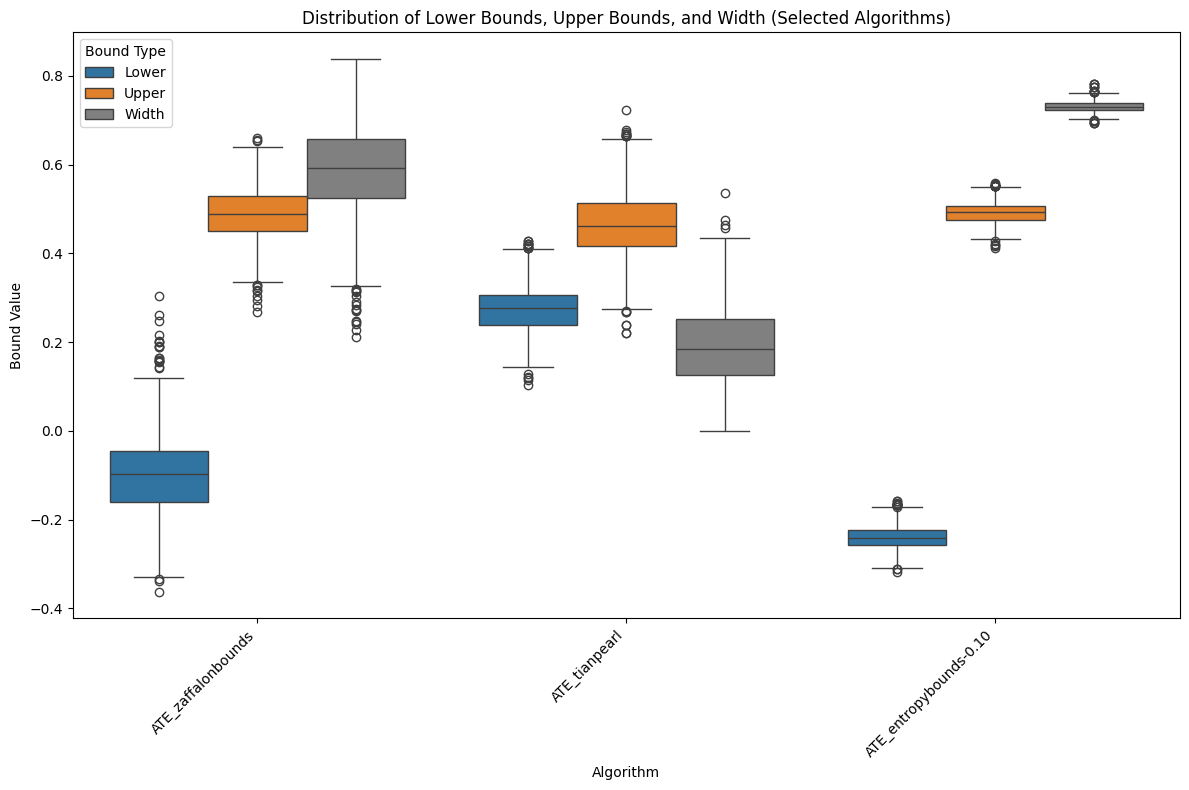

In [18]:
# Initialize a dictionary to hold the statistics
stats = {
    'Algorithm': [],
    'Mean Lower Bound': [],
    'Std Dev Lower Bound': [],
    'Mean Upper Bound': [],
    'Std Dev Upper Bound': [],
    'Percentage Failed': [],
    'Percentage Valid': [],
}

# Loop through each algorithm
for alg in Algs:
    # Compute statistics for lower and upper bounds
    lower = results_variance[f'{alg}_bound_lower']
    upper = results_variance[f'{alg}_bound_upper']
    
    mean_lower = lower.mean()
    std_lower = lower.std()

    mean_upper = upper.mean()
    std_upper = upper.std()

    percentage_failed = results_variance[f'{alg}_bound_failed'].mean() * 100
    percentage_valid = results_variance[f'{alg}_bound_valid'].mean() * 100

    # Append to dictionary
    stats['Algorithm'].append(alg)
    stats['Mean Lower Bound'].append(mean_lower)
    stats['Std Dev Lower Bound'].append(std_lower)
    stats['Mean Upper Bound'].append(mean_upper)
    stats['Std Dev Upper Bound'].append(std_upper)
    stats['Percentage Failed'].append(percentage_failed)
    stats['Percentage Valid'].append(percentage_valid)

# Create and display the DataFrame
stats_df = pd.DataFrame(stats)
print(stats_df)


filtered_algs =['ATE_zaffalonbounds', 'ATE_tianpearl', 'ATE_entropybounds-0.10']

# Create boxplot data for upper, lower bounds, and width (only filtered algorithms)
boxplot_data = []
for alg in filtered_algs:
    lower_bounds = results_variance[f'{alg}_bound_lower'].dropna()
    upper_bounds = results_variance[f'{alg}_bound_upper'].dropna()
    bound_widths = results_variance[f'{alg}_bound_width'].dropna()
    
    # Add lower bounds
    for val in lower_bounds:
        boxplot_data.append({'Algorithm': alg, 'Bound Type': 'Lower', 'Value': val})
    
    # Add bound widths (in the middle)
    for val in bound_widths:
        boxplot_data.append({'Algorithm': alg, 'Bound Type': 'Width', 'Value': val})
    
    # Add upper bounds
    for val in upper_bounds:
        boxplot_data.append({'Algorithm': alg, 'Bound Type': 'Upper', 'Value': val})

boxplot_df = pd.DataFrame(boxplot_data)

# Create the boxplot with custom colors
plt.figure(figsize=(12, 8))
# Define custom color palette with grey for Width at the end
colors = ['#1f77b4', '#ff7f0e', '#808080']  # blue, orange, grey  
ax = sns.boxplot(data=boxplot_df, x='Algorithm', y='Value', hue='Bound Type', 
                 hue_order=['Lower', 'Upper', 'Width'], palette=colors)
plt.xticks(rotation=45, ha='right')
plt.title('Distribution of Lower Bounds, Upper Bounds, and Width (Selected Algorithms)')
plt.ylabel('Bound Value')
plt.tight_layout()
plt.show()

In [ ]:
# expect dataset named results_variance
#loop through each algorithm (given variables ATE_Algs, PNS_Algs and Algs)
## measure the mean and std deviation of {algname}_bound_width.
## measure how many % of the executions failed: {algname}_bound_failed (boolean)
## mease how many % of the exections were valid: {algname}_bound_valid (boolean)
## measure the avg. invalid distance: of those that were invalid, how far was the upper/lowerbound from the {query}_true for query in {ATE, PNS}
# print all theses statics in a table, each algorithm in a row, each statistic in a column

ATE_Algs = scenario.get_algorithms('ATE')
PNS_Algs = scenario.get_algorithms('PNS')
# concatenate the two lists
Algs = ATE_Algs + PNS_Algs

# Initialize a dictionary to hold the statistics
stats = {
    'Algorithm': [],
    'Mean Bound Width': [],
    'Std Dev Bound Width': [],
    'Percentage Failed': [],
    'Percentage Valid': [],

}
# Loop through each algorithm
for alg in Algs:
    #calulate statistics
    mean_bound_width = results_variance[f'{alg}_bound_width'].mean()
    std_bound_width = results_variance[f'{alg}_bound_width'].std()
    percentage_failed = results_variance[f'{alg}_bound_failed'].mean() * 100
    percentage_valid = results_variance[f'{alg}_bound_valid'].mean() * 100

    # extract query: cols are of the form {query}_{alg}_...
    query = alg.split('_')[0]  # Extract the query part from the algorithm name

    # Append the statistics to the dictionary
    stats['Algorithm'].append(alg)
    stats['Mean Bound Width'].append(mean_bound_width)
    stats['Std Dev Bound Width'].append(std_bound_width)
    stats['Percentage Failed'].append(percentage_failed)
    stats['Percentage Valid'].append(percentage_valid)

# Create a DataFrame from the statistics dictionary
stats_df = pd.DataFrame(stats)
# Display the DataFrame
stats_df

,Algorithm,Mean Bound Width,Std Dev Bound Width,Percentage Failed,Percentage Valid
0,ATE_OLS-0.99,0.233279,8.795372e-03,0.0,0.05
1,ATE_OLS-0.98,0.210685,7.943498e-03,0.0,0.05
2,ATE_OLS-0.95,0.177504,6.692452e-03,0.0,0.05
3,ATE_causaloptim,1.000000,2.720160e-17,0.0,100.00
4,ATE_autobound,1.000000,1.773327e-17,0.0,100.00
5,ATE_entropybounds-0.80,0.999999,5.553265e-06,0.0,0.05
6,ATE_entropybounds-0.20,0.916841,9.641261e-03,0.0,0.05
7,ATE_entropybounds-0.10,0.731170,1.169765e-02,0.0,0.05
8,ATE_entropybounds-trueTheta,0.999996,9.363686e-06,0.0,0.05
9,ATE_entropybounds-randomTheta,0.932681,1.572821e-01,0.0,0.05


In [ ]:
#levenes test
# expect dataset named results_variance
#loop through each algorithm (given variables ATE_Algs, PNS_Algs and Algs)
## measure the mean and std deviation of {algname}_bound_width.
## measure how many % of the executions failed: {algname}_bound_failed (boolean)
## mease how many % of the exections were valid: {algname}_bound_valid (boolean)
## measure the avg. invalid distance: of those that were invalid, how far was the upper/lowerbound from the {query}_true for query in {ATE, PNS}
# print all theses statics in a table, each algorithm in a row, each statistic in a column

ATE_Algs = scenario.get_algorithms('ATE')
PNS_Algs = scenario.get_algorithms('PNS')
# concatenate the two lists
Algs = ATE_Algs + PNS_Algs

#@TODO: Display mean/std of upper and lower bound?

from scipy import stats as scipy_stats

# Collect all bound widths for variance homogeneity test
all_bound_widths = []
for alg in Algs:
    bound_widths = results_variance[f'{alg}_bound_width'].dropna()
    all_bound_widths.append(bound_widths)

# Perform Levene's test for homogeneity of variances
levene_stat, levene_p = scipy_stats.levene(*all_bound_widths)

# Perform ANOVA to test if means are significantly different
anova_stat, anova_p = scipy_stats.f_oneway(*all_bound_widths)

print(f"Levene's test for equal variances: statistic = {levene_stat:.4f}, p-value = {levene_p:.4f}")
print(f"ANOVA test for equal means: statistic = {anova_stat:.4f}, p-value = {anova_p:.4f}")
print()

# Initialize a dictionary to hold the statistics
stats = {
    'Algorithm': [],
    'Mean Bound Width': [],
    'Std Dev Bound Width': [],
    'Coefficient of Variation': [],
    'Percentage Failed': [],
    'Percentage Valid': [],
    # 'Avg Invalid Distance Upper Bound': [],
    # 'Avg Invalid Distance Lower Bound': []
}

# Loop through each algorithm
for alg in Algs:
    #calulate statistics
    bound_widths = results_variance[f'{alg}_bound_width'].dropna()
    mean_bound_width = bound_widths.mean()
    std_bound_width = bound_widths.std()
    
    # Calculate coefficient of variation (CV = std/mean) to measure relative variability
    cv = std_bound_width / mean_bound_width if mean_bound_width != 0 else np.nan
    
    percentage_failed = results_variance[f'{alg}_bound_failed'].mean() * 100
    percentage_valid = results_variance[f'{alg}_bound_valid'].mean() * 100

    # extract query: cols are of the form {query}_{alg}_...
    query = alg.split('_')[0]  # Extract the query part from the algorithm name
    # avg_invalid_distance_upper = results_variance[results_variance[f'{alg}_bound_valid'] == False][f'{alg}_bound_upper'].mean() - results_variance[f'{query}_true'].mean()
    # avg_invalid_distance_lower = results_variance[results_variance[f'{alg}_bound_valid'] == False][f'{alg}_bound_lower'].mean() - results_variance[f'{query}_true'].mean()
    # Append the statistics to the dictionary
    stats['Algorithm'].append(alg)
    stats['Mean Bound Width'].append(mean_bound_width)
    stats['Std Dev Bound Width'].append(std_bound_width)
    stats['Coefficient of Variation'].append(cv)
    stats['Percentage Failed'].append(percentage_failed)
    stats['Percentage Valid'].append(percentage_valid)
    # stats['Avg Invalid Distance Upper Bound'].append(avg_invalid_distance_upper)
    # stats['Avg Invalid Distance Lower Bound'].append(avg_invalid_distance_lower)

# Create a DataFrame from the statistics dictionary
stats_df = pd.DataFrame(stats)

# Add overall test results as a note
print(f"Overall variance homogeneity test (Levene): p = {levene_p:.4f}")
print(f"Overall mean equality test (ANOVA): p = {anova_p:.4f}")
print(f"Interpretation: p > 0.05 suggests no significant difference")
print()

# Display the DataFrame
stats_df

count    2000.000000
mean        0.675859
std         0.021264
min         0.612000
25%         0.662000
50%         0.676000
75%         0.690000
max         0.734000
Name: PNS_tianpearl_bound_width, dtype: float64

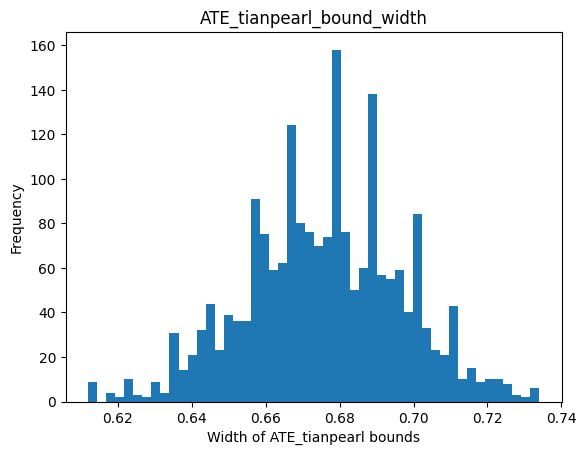

In [ ]:
results_variance['PNS_tianpearl_bound_width'].plot(kind='hist', bins=50, title='ATE_tianpearl_bound_width', xlabel='Width of ATE_tianpearl bounds', ylabel='Frequency')
results_variance['PNS_tianpearl_bound_width'].describe()

In [10]:
results_variance['PNS_tianpearl_bound_valid'].value_counts()

PNS_tianpearl_bound_valid
True    2000
Name: count, dtype: int64